## Cell 1: Install & Import Dependencies

In [1]:
# Install required packages
!pip install -q ultralytics opencv-python pyyaml

# Imports
import os
import sys
from pathlib import Path
from ultralytics import YOLO
import yaml
import torch

print("✓ Dependencies installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Dependencies installed
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Cell 2: Mount Google Drive & Configure Paths

In [2]:
# Mount Google Drive (ONLY for Colab users)
try:
    from google.colab import drive
    print("📂 Mounting Google Drive...")
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
    print("\nYour Drive location: /content/drive/MyDrive")
except:
    print("ℹ Not in Google Colab or Drive already mounted")
    print("  If using Colab, uncomment lines above to mount Drive")

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted

Your Drive location: /content/drive/MyDrive


In [3]:
# ===== GOOGLE DRIVE CONFIGURATION =====

print("🔧 Setting up Google Drive access...\n")

# Google Drive paths (UPDATE THESE IF YOUR FOLDER IS IN A DIFFERENT LOCATION)
DRIVE_PATH = "/content/drive/MyDrive"
PROJECT_FOLDER = "smart-dental-ai"  # ← Change if your folder name is different

# Full paths
BASE_DIR = os.path.join(DRIVE_PATH, PROJECT_FOLDER)
DATASET_DIR = os.path.join(BASE_DIR, "datasets")
OUTPUT_DIR = os.path.join(BASE_DIR, "runs/detection-results")

# Dataset structure
DETECTION_DATASET = os.path.join(DATASET_DIR, 'detection-dataset')
DATA_YAML = os.path.join(DETECTION_DATASET, 'data.yaml')
TRAIN_IMG_DIR = os.path.join(DETECTION_DATASET, 'images/train')
VAL_IMG_DIR = os.path.join(DETECTION_DATASET, 'images/val')

print(f"📁 Project folder: {BASE_DIR}")
print(f"📁 Dataset: {DATASET_DIR}")
print(f"📁 Output: {OUTPUT_DIR}\n")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify dataset exists
if os.path.exists(DETECTION_DATASET):
    print(f"✓ Dataset found at {DETECTION_DATASET}")
    try:
        train_count = len([f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        val_count = len([f for f in os.listdir(VAL_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  ✓ Training images: {train_count}")
        print(f"  ✓ Validation images: {val_count}")
    except Exception as e:
        print(f"  ⚠ Error reading images: {e}")
else:
    print(f"✗ Dataset NOT found at {DETECTION_DATASET}")
    print(f"\n📂 Expected folder structure on Google Drive:")
    print(f"   {PROJECT_FOLDER}/")
    print(f"   ├── datasets/")
    print(f"   │   └── detection-dataset/")
    print(f"   │       ├── images/")
    print(f"   │       │   ├── train/ (your training images)")
    print(f"   │       │   └── val/ (your validation images)")
    print(f"   │       ├── labels/")
    print(f"   │       │   ├── train/ (label files)")
    print(f"   │       │   └── val/")
    print(f"   │       └── data.yaml")
    print(f"   └── runs/ (will be created for results)")
    print(f"\n💡 Make sure your dataset matches this structure on Google Drive!")

🔧 Setting up Google Drive access...

📁 Project folder: /content/drive/MyDrive/smart-dental-ai
📁 Dataset: /content/drive/MyDrive/smart-dental-ai/datasets
📁 Output: /content/drive/MyDrive/smart-dental-ai/runs/detection-results

✓ Dataset found at /content/drive/MyDrive/smart-dental-ai/datasets/detection-dataset
  ✓ Training images: 1493
  ✓ Validation images: 49


## Cell 3: Verify data.yaml Configuration

In [4]:
# Read and display data.yaml
if os.path.exists(DATA_YAML):
    with open(DATA_YAML, 'r') as f:
        config = yaml.safe_load(f)

    print("📋 data.yaml Configuration:")
    print(f"  Number of classes: {config.get('nc')}")
    print(f"  Classes: {config.get('names')}")
    print(f"  Train path: {config.get('train')}")
    print(f"  Val path: {config.get('val')}")
else:
    print(f"✗ data.yaml not found at {DATA_YAML}")

📋 data.yaml Configuration:
  Number of classes: 4
  Classes: {0: 'Data_caries', 1: 'Mouth_Ulcer', 2: 'Tooth_Discoloration', 3: 'Gingivitis'}
  Train path: images/train
  Val path: images/val


## Cell 4: Train YOLOv8 Model

In [5]:
# Training configuration
MODEL_NAME = "yolov8m"
EPOCHS = 100
BATCH_SIZE = 16
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print(f"🚀 Starting YOLOv8 Training")
print(f"  Model: {MODEL_NAME}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Device: {DEVICE}")
print(f"  Dataset: {DATA_YAML}\n")

# Load model
model = YOLO(f"{MODEL_NAME}.pt")
print("✓ Model loaded\n")

# Train
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    patience=10,
    save=True,
    save_period=5,
    cache="ram",
    # Augmentation
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5,
    translate=0.05,
    scale=0.3,
    flipud=0.3,
    fliplr=0.3,
    mosaic=0.8,
    mixup=0.0,
    # Output settings
    name="yolov8m_dental_detection",
    project=os.path.join(OUTPUT_DIR, "detection"),
    exist_ok=True,
    verbose=True,
)

print("\n✓ Training completed!")

🚀 Starting YOLOv8 Training
  Model: yolov8m
  Epochs: 100
  Batch size: 16
  Device: 0
  Dataset: /content/drive/MyDrive/smart-dental-ai/datasets/detection-dataset/data.yaml

✓ Model loaded

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/smart-dental-ai/datasets/detection-dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, ma

## Cell 5: Display Training Results

📊 Training Results:
  Best model: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/detection/yolov8m_dental_detection/weights/best.pt
  Results dir: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/detection/yolov8m_dental_detection

📈 Visualization plots:

  BoxF1_curve.png:


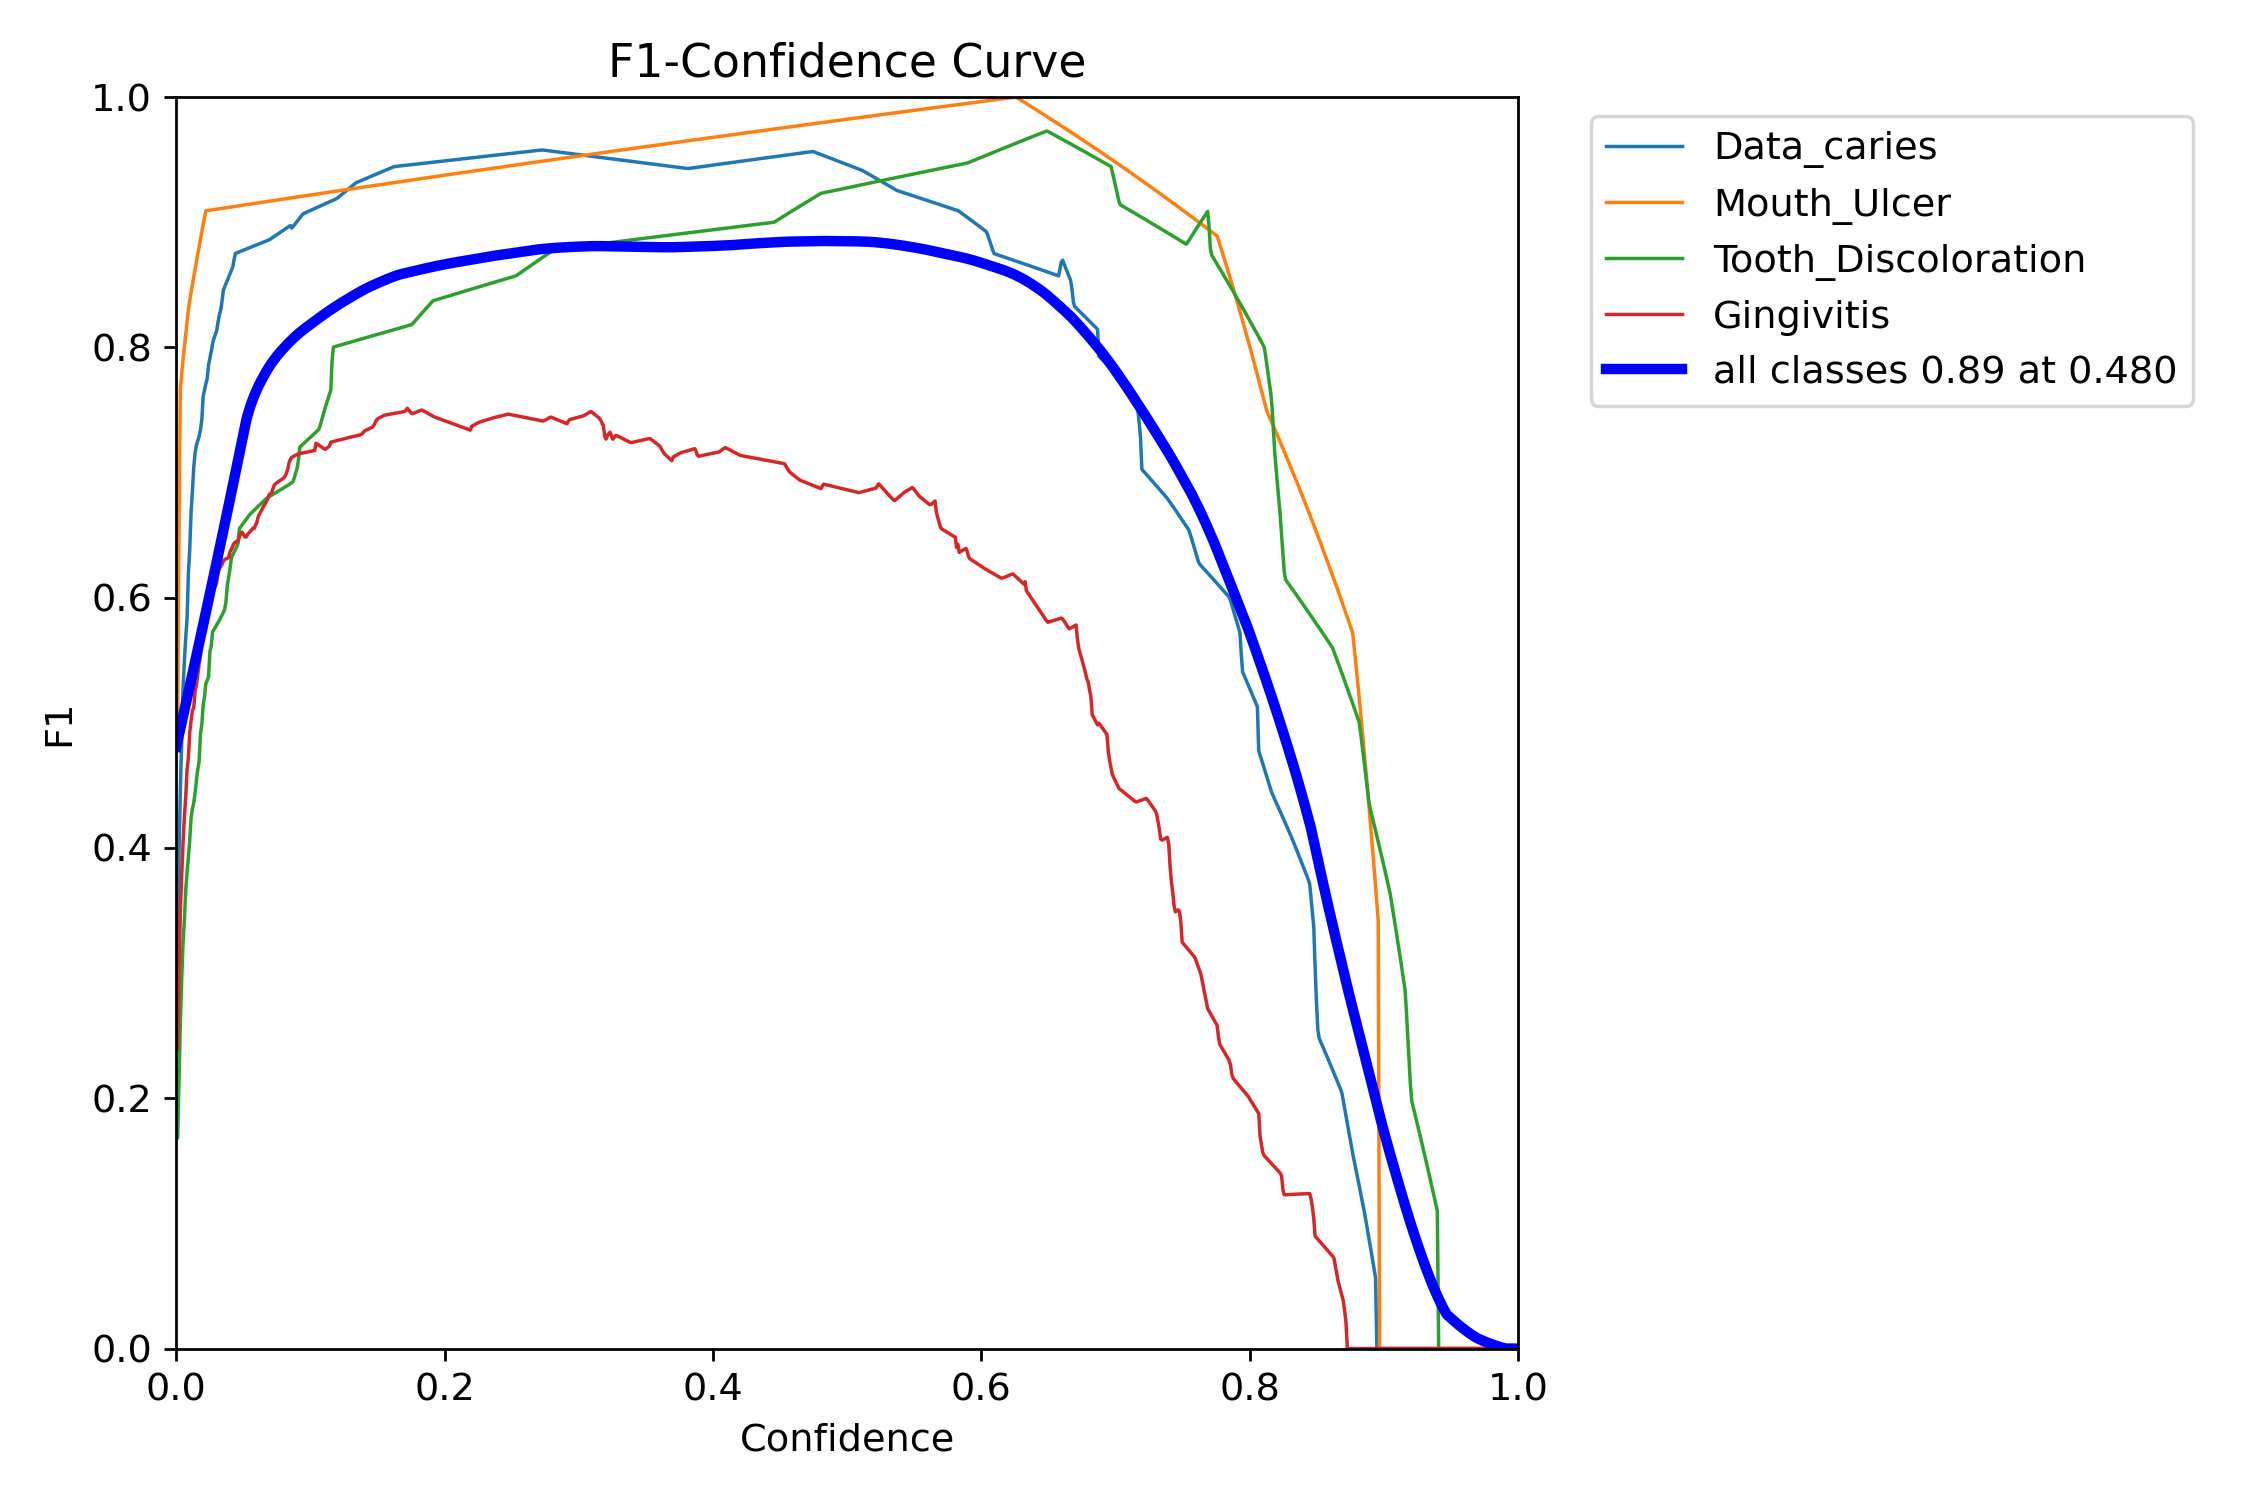


  BoxPR_curve.png:


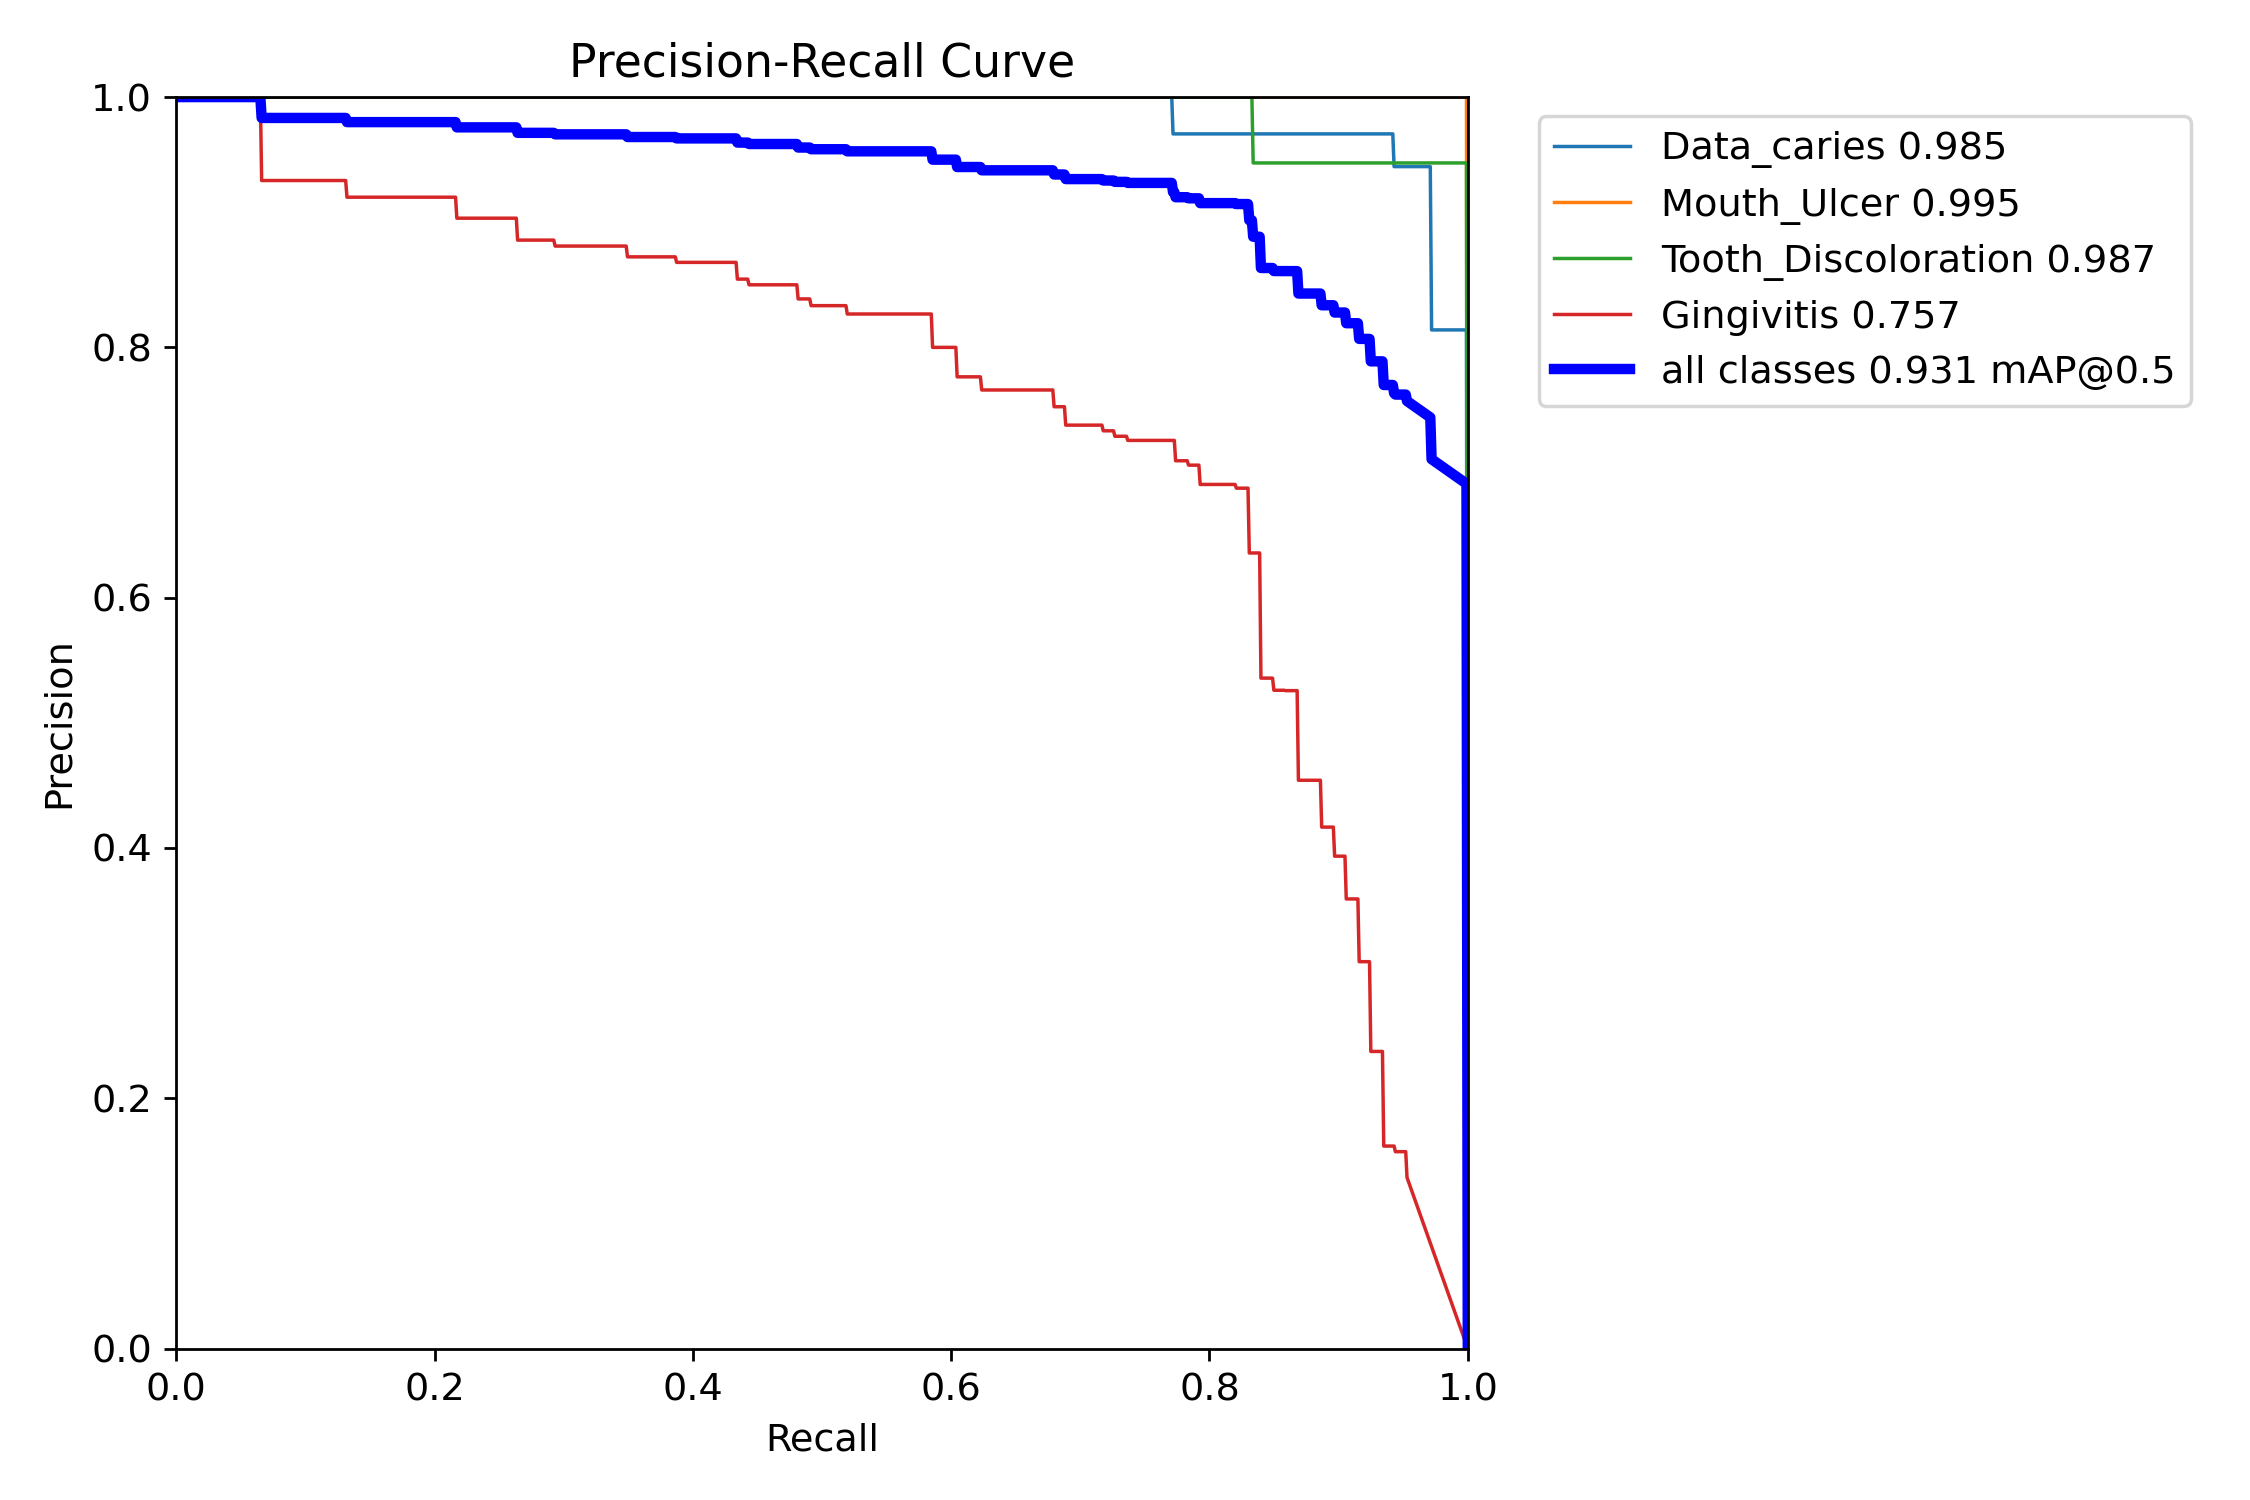


  BoxP_curve.png:


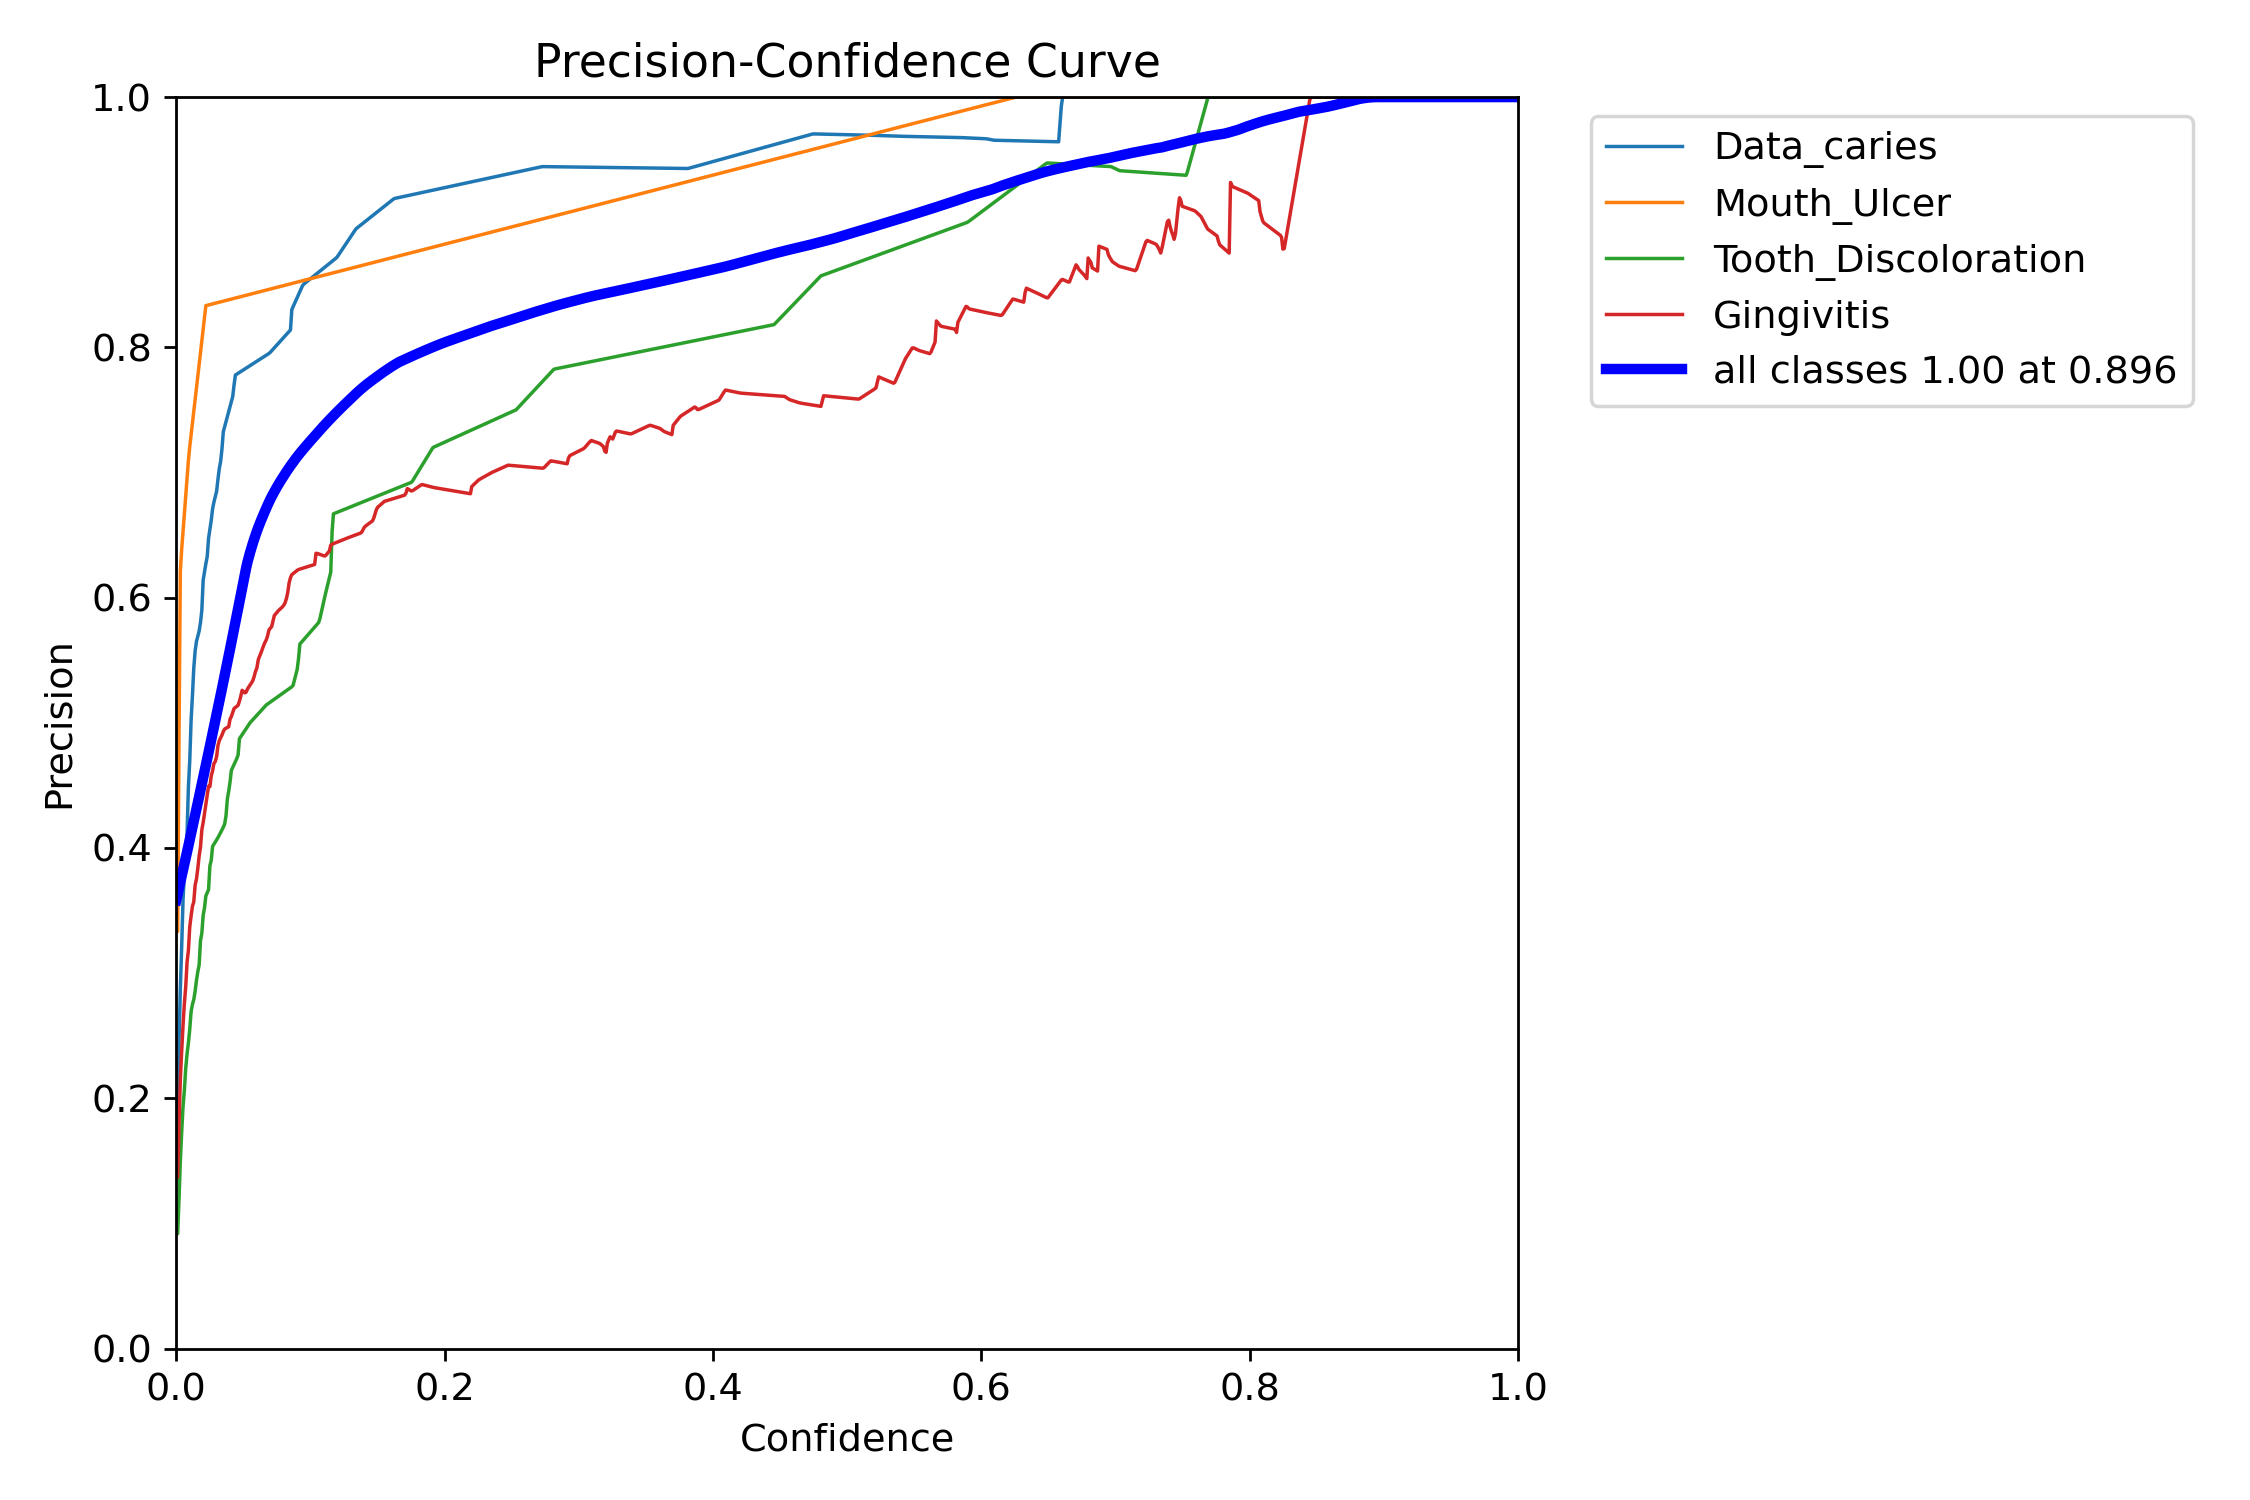

In [6]:
# Display results summary
print("📊 Training Results:")
print(f"  Best model: {results.save_dir}/weights/best.pt")
print(f"  Results dir: {results.save_dir}")

# Try to display plots if available
from IPython.display import Image, display
import glob

results_dir = results.save_dir
plot_files = glob.glob(os.path.join(results_dir, "*.png"))

if plot_files:
    print("\n📈 Visualization plots:")
    for plot_file in sorted(plot_files)[:3]:  # Show first 3 plots
        print(f"\n  {os.path.basename(plot_file)}:")
        display(Image(filename=plot_file, width=600))

## Cell 6: Evaluate Model on Validation Set

In [7]:
# Load best model and evaluate
best_model_path = os.path.join(results.save_dir, "weights/best.pt")
model = YOLO(best_model_path)

print("🔍 Evaluating on validation set...\n")
metrics = model.val(
    data=DATA_YAML,
    conf=0.5,
    iou=0.45,
    device=DEVICE,
)

print("\n✓ Evaluation complete")
print(f"\n📋 Metrics Summary:")
if hasattr(metrics, 'results_dict'):
    for key, value in sorted(metrics.results_dict.items()):
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")

🔍 Evaluating on validation set...

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 5.9±3.6 MB/s, size: 21.4 KB)
val: Scanning /content/drive/MyDrive/smart-dental-ai/datasets/detection-dataset/labels/val.cache... 43 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 12.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.4s
                   all         49        164      0.919      0.884      0.907       0.65
           Data_caries          8         35       0.97      0.914      0.951      0.798
           Mouth_Ulcer          5          5          1          1      0.995      0.751
   Tooth_Discoloration         10         18      0.947          1      0.987      0.746
            Gingivitis         20        106      0.759      0.6

## Cell 7: Test Inference on Sample Image

🧪 Testing inference on: 602.jpg


image 1/1 /content/drive/MyDrive/smart-dental-ai/datasets/detection-dataset/images/val/602.jpg: 640x640 1 Tooth_Discoloration, 36.9ms
Speed: 3.7ms preprocess, 36.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
✓ Detections: 1 objects found

  Detected classes:
    - Tooth_Discoloration: 87.01%


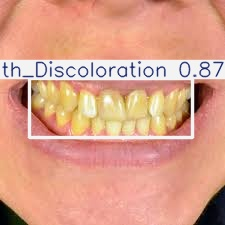

In [8]:
# Run inference on first validation image
import random

val_images = [f for f in os.listdir(VAL_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if val_images:
    test_image_path = os.path.join(VAL_IMG_DIR, random.choice(val_images))
    print(f"🧪 Testing inference on: {os.path.basename(test_image_path)}\n")

    inference_results = model.predict(test_image_path, conf=0.5)

    if inference_results and len(inference_results) > 0:
        detection = inference_results[0]
        num_detections = len(detection.boxes)
        print(f"✓ Detections: {num_detections} objects found\n")

        if num_detections > 0:
            print("  Detected classes:")
            for box in detection.boxes:
                class_id = int(box.cls[0])
                class_name = detection.names[class_id]
                confidence = float(box.conf[0])
                print(f"    - {class_name}: {confidence:.2%}")

        # Display result image
        result_image = detection.plot()
        import cv2
        cv2.imwrite('/tmp/detection_result.jpg', result_image)
        display(Image(filename='/tmp/detection_result.jpg', width=600))
else:
    print("✗ No validation images found")

## Cell 8: Download Trained Model

**For Kaggle:** Model is already in `/kaggle/working`

**For Colab:** Run the cell below to download

In [10]:
import shutil
from datetime import datetime

# ✓ Use the training results saved earlier
print(f"📦 Packaging trained model...\n")

model_dir = results.save_dir
download_name = f"yolov8s_dental_detection_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
download_path = os.path.join(OUTPUT_DIR, download_name)

print(f"  Source: {model_dir}")
print(f"  Destination: {download_path}\n")

if os.path.exists(model_dir):
    shutil.copytree(model_dir, download_path, dirs_exist_ok=True)
    print(f"✓ Model packaged successfully!")
    print(f"\n📥 Download these files from your Google Drive:")
    print(f"  📄 Best weights: {os.path.join(download_path, 'weights/best.pt')}")
    print(f"  📊 Training results: {download_path}")
    print(f"\n💾 Location: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/{download_name}")
else:
    print(f"✗ Model directory not found: {model_dir}")
    print(f"  Make sure training completed successfully")

📦 Packaging trained model...

  Source: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/detection/yolov8m_dental_detection
  Destination: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/yolov8s_dental_detection_20260309_185956

✓ Model packaged successfully!

📥 Download these files from your Google Drive:
  📄 Best weights: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/yolov8s_dental_detection_20260309_185956/weights/best.pt
  📊 Training results: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/yolov8s_dental_detection_20260309_185956

💾 Location: /content/drive/MyDrive/smart-dental-ai/runs/detection-results/yolov8s_dental_detection_20260309_185956
